<a href="https://colab.research.google.com/github/alyssaplayer/BU_OMDS_APlayerRepo/blob/main/Mod_6_Experimental_Design_Coding_Quizzes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##DX702: Experimental Design and Causality 
#Weekly Coding Quizzes - Deep 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Week 1: Linear Regression

In [ ]:
#Week 1&2 Coding Quiz:
#load the data
data_dir = 'homework files - exp design'
df_1 = pd.read_csv(f'{data_dir}/homework_1.1.csv')
df_2 = pd.read_csv(f'{data_dir}/homework_1.2.csv')

print(df_1.head())
print(df_2.head())


FileNotFoundError: [Errno 2] No such file or directory: 'homework_1.1.csv'

Question 1: Which of the following is closest to the coefficient of X1?

1

[1.00713766 1.96456859 2.97548854]

R² Score: 0.9907


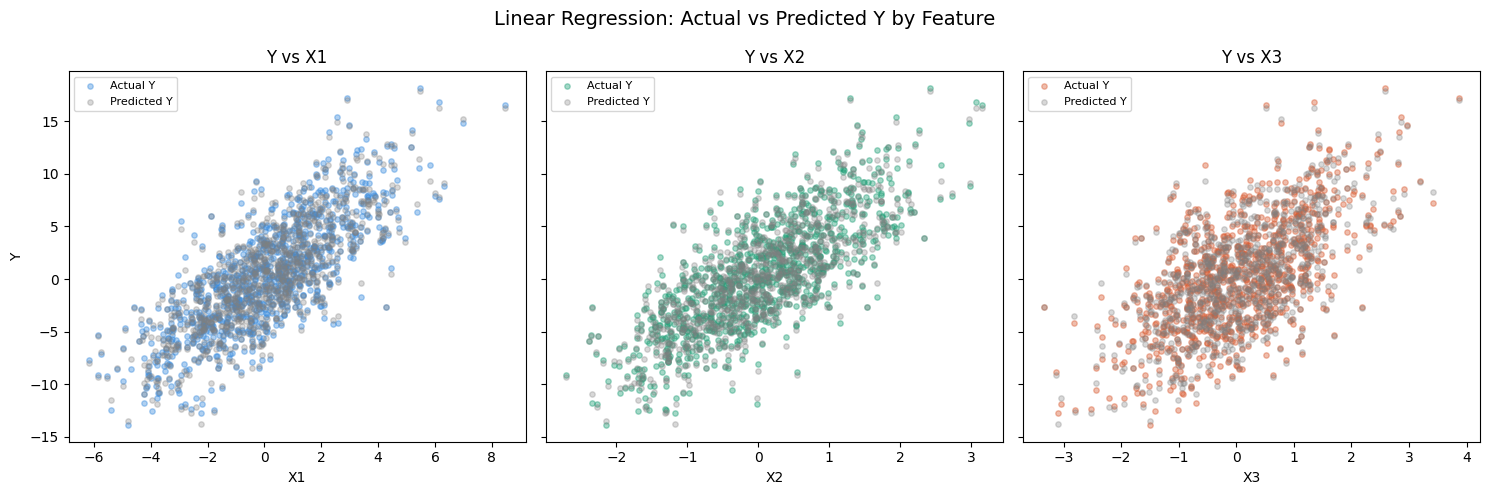

In [ ]:
from sklearn.linear_model import LinearRegression

X = df_1[['X1', 'X2', 'X3']]
y = df_1['Y']

model = LinearRegression()
model.fit(X, y)
model.coef_

print(model.coef_)


from sklearn.metrics import r2_score
y_pred = model.predict(X)
print(f"\nR² Score: {r2_score(y, y_pred):.4f}")

features = ['X1', 'X2', 'X3']
colors = ['#378ADD', '#1D9E75', '#D85A30']   # blue, teal, coral

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Linear Regression: Actual vs Predicted Y by Feature', fontsize=14)

for ax, feat, color in zip(axes, features, colors):
    ax.scatter(df_1[feat], y, alpha=0.4, s=15, color=color, label='Actual Y')
    ax.scatter(df_1[feat], y_pred, alpha=0.3, s=15, color='gray', label='Predicted Y')

    ax.set_xlabel(feat)
    ax.set_title(f'Y vs {feat}')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Y')
plt.tight_layout()
plt.show()

Question 2
Which Xi has the greatest difference between the amount Y increases for each 1 unit of Xi (fixing the other Xi’s), as opposed to the amount that Y increases for each 1 unit of Xi in the dataset, on average (not fixing the other Xis)? Hint: for the former, you'll have to regress Y on Xi alone, while for the latter, you'll have to regress Y on all three Xis.

In [ ]:
from sklearn.linear_model import LinearRegression

features = ['X1', 'X2', 'X3']

# Coefficients from the full multiple regression (you already have these)
multi_coefs = model.coef_  # [1.007, 1.965, 2.975]

# Now regress Y on each Xi alone
simple_coefs = []
for feat in features:
    m = LinearRegression()
    m.fit(df_1[[feat]], y)
    simple_coefs.append(m.coef_[0])

# Compare the differences
for feat, sc, mc in zip(features, simple_coefs, multi_coefs):
    print(f"{feat}: simple={sc:.4f}, multiple={mc:.4f}, diff={abs(sc-mc):.4f}")

X1: simple=1.8418, multiple=1.0071, diff=0.8346
X2: simple=4.0836, multiple=1.9646, diff=2.1190
X3: simple=3.0970, multiple=2.9755, diff=0.1216


X1: simple=1.8418, multiple=1.0071, diff=0.8346
X2: simple=4.0836, multiple=1.9646, diff=2.1190
X3: simple=3.0970, multiple=2.9755, diff=0.1216
the answer is X2

**Question 3**
When regressing Y on all Xis together, which coefficient is most significant, considering the t-statistic as a measure of significance?

In [ ]:
import statsmodels.api as sm

# Add a constant (intercept) to X
X_with_const = sm.add_constant(df_1[['X1', 'X2', 'X3']])

# Fit the model
ols_model = sm.OLS(y, X_with_const).fit()

# Print the summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 3.543e+04
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        02:07:01   Log-Likelihood:                -727.62
No. Observations:                1000   AIC:                             1463.
Df Residuals:                     996   BIC:                             1483.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0026      0.016      0.166      0.8

a high t-statistic means you can be confident that the coefficient is real and not just noise - st error of x3 is 0.015, and the t statistic is 196.645

For Question 4 and 5:


Use NearestNeighbors to match data based on variables Z, given the file homework_1.2.csv.
Pick the best match in X = 0 corresponding to each X = 1. Use the Z values to perform the match: a good match with X = 1 is the item whose Z value is closest to the given sample's Z value with X = 0. I suggest using sklearn's NearestNeighbors to do this, but there are many ways to do it.  

In [ ]:
from sklearn.neighbors import NearestNeighbors

group_0 = df_2[df_2['X'] == 0]
group_1 = df_2[df_2['X'] == 1]

nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nbrs.fit(group_0[['Z']])

distances, indices = nbrs.kneighbors(group_1[['Z']])

matched = pd.DataFrame({
    'Z_treatment': group_1['Z'].values,
    'Y_treatment': group_1['Y'].values,
    'Z_matched':   group_0['Z'].iloc[indices.flatten()].values,
    'Y_matched':   group_0['Y'].iloc[indices.flatten()].values,
    'distance':    distances.flatten()
})

print(matched.head(10))
print(distances.max())
print(df_2['Z'].std())

   Z_treatment  Y_treatment  Z_matched  Y_matched  distance
0     0.715189     1.215189   0.716327   0.716327  0.001138
1     0.645894     1.145894   0.653108   0.653108  0.007214
2     0.437587     0.937587   0.437032   0.437032  0.000555
3     0.891773     1.391773   0.778157   0.778157  0.113616
4     0.963663     1.463663   0.778157   0.778157  0.185506
5     0.383442     0.883442   0.414662   0.414662  0.031220
6     0.791725     1.291725   0.778157   0.778157  0.013568
7     0.925597     1.425597   0.778157   0.778157  0.147440
8     0.832620     1.332620   0.778157   0.778157  0.054463
9     0.870012     1.370012   0.778157   0.778157  0.091855
0.2102170871093757
0.2897540152400463


Question 4: What is the distance of the farthest match in this set?

0.210217

Question 5:
What is the effect? (The difference between the average Y value for X = 0 values vs. the average Y value for X = 1, where the X = 0 sample has the best match for each X = 1 value). So we use the matched sample of X = 0 and the full sample of X = 1.

In [ ]:
effect = group_1['Y'].mean() - matched['Y_matched'].mean()
print(effect)

0.5433600652185839


For questions 6 and 7:

Use NearestNeighbors to match data based on variables Z, given the file homework_1.2.csv.
Try approach B: Pick all of the matches in X = 0 that are within a distance 0.2 of each X = 1. Duplicates are okay, in case a given sample with X = 0 is a good match for multiple items with X = 1.

In [ ]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(algorithm='ball_tree', radius=0.2)
nbrs.fit(group_0[['Z']])

# radius_neighbors returns all matches within distance 0.2
distances_r, indices_r = nbrs.radius_neighbors(group_1[['Z']])

# Build matched dataframe - note each X=1 sample may have multiple matches
rows = []
for i, (dists, idxs) in enumerate(zip(distances_r, indices_r)):
    for d, j in zip(dists, idxs):
        rows.append({
            'Z_treatment': group_1['Z'].iloc[i],
            'Y_treatment': group_1['Y'].iloc[i],
            'Z_matched':   group_0['Z'].iloc[j],
            'Y_matched':   group_0['Y'].iloc[j],
            'distance':    d
        })

matched_r = pd.DataFrame(rows)
print(f"Total matches: {len(matched_r)}")
print(matched_r.head(10))

Total matches: 737
   Z_treatment  Y_treatment  Z_matched  Y_matched  distance
0     0.715189     1.215189   0.548814   0.548814  0.166376
1     0.715189     1.215189   0.602763   0.602763  0.112426
2     0.715189     1.215189   0.544883   0.544883  0.170306
3     0.715189     1.215189   0.528895   0.528895  0.186294
4     0.715189     1.215189   0.568045   0.568045  0.147145
5     0.715189     1.215189   0.778157   0.778157  0.062967
6     0.715189     1.215189   0.521848   0.521848  0.193341
7     0.715189     1.215189   0.616934   0.616934  0.098255
8     0.715189     1.215189   0.666767   0.666767  0.048423
9     0.715189     1.215189   0.670638   0.670638  0.044551


**Question 6**

How many duplicates do you end up with? (Count all but the first duplicate in each group. One way to do this is to use radius_neighbors.)

In [ ]:
print(matched_r)

     Z_treatment  Y_treatment  Z_matched  Y_matched  distance
0       0.715189     1.215189   0.548814   0.548814  0.166376
1       0.715189     1.215189   0.602763   0.602763  0.112426
2       0.715189     1.215189   0.544883   0.544883  0.170306
3       0.715189     1.215189   0.528895   0.528895  0.186294
4       0.715189     1.215189   0.568045   0.568045  0.147145
..           ...          ...        ...        ...       ...
732     0.828940     1.328940   0.670638   0.670638  0.158302
733     0.828940     1.328940   0.653108   0.653108  0.175832
734     0.828940     1.328940   0.656330   0.656330  0.172610
735     0.828940     1.328940   0.739264   0.739264  0.089676
736     0.828940     1.328940   0.716327   0.716327  0.112613

[737 rows x 5 columns]


In [ ]:
duplicate_counts = matched_r['Z_matched'].value_counts()
num_duplicates = duplicate_counts[duplicate_counts > 1].sum() - len(duplicate_counts[duplicate_counts > 1])

print(f"Number of duplicates (all but the first): {num_duplicates}")

Number of duplicates (all but the first): 685


**Question 7**
What is the effect? (Note: to compute the effect, you should take the mean of the Y values in each neighbor group, then average the Y for each group.)

In [ ]:
group_means = [
    group_0['Y'].iloc[idxs].mean()
    for idxs in indices_r
    if len(idxs) > 0
]

avg_y_control = np.mean(group_means)
avg_y_treatment = group_1['Y'].iloc[:len(group_means)].mean()

effect = avg_y_treatment - avg_y_control
print(f"Avg Y for X=1: {avg_y_treatment:.4f}")
print(f"Avg Y for X=0 (matched): {avg_y_control:.4f}")
print(f"Effect: {effect:.4f}")

Avg Y for X=1: 1.1220
Avg Y for X=0 (matched): 0.5412
Effect: 0.5808


# Week 2: Simulation and Fixed Effects

In [ ]:
df2_1 = pd.read_csv('homework_2.1.csv')
df2_2 = pd.read_csv('homework_2.2.csv')

print(df2_1.head())
print(df2_2.head())

   time        G1        G2        G3
0     0  0.882026  1.441575  0.065409
1     1  0.210079 -0.163880  0.140310
2     2  0.509369 -0.115242  0.819830
3     3  1.150447  1.014698  0.607632
4     4  0.973779 -0.046562  0.610066
   X          Y         Z
0  0   1.182435 -0.725820
1  0   2.714474  0.563476
2  0   0.077612 -0.435632
3  0  -0.154449 -0.104553
4  0  22.298992 -2.321273


For questions 1 and 2:

Do a regression to estimate the fixed effect of each group. We assume that there is one single linear coefficient for all the data, plus the fixed effect of each group. Use the file homework_2.1.csv.  The variables G1, G2, and G3 are the outcomes and the time is the treatment.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

df = pd.read_csv('homework_2.1.csv')

# Reshape wide → long
df_long = df.melt(id_vars='time', value_vars=['G1','G2','G3'],
                  var_name='group', value_name='outcome')

# Create group dummies (keep all 3 — no reference group needed when fit_intercept=False)
dummies = pd.get_dummies(df_long['group'])

# X = time + group dummies, y = outcome
X = pd.concat([df_long[['time']], dummies], axis=1)
y = df_long['outcome']

reg = LinearRegression(fit_intercept=False).fit(X, y)

for name, coef in zip(X.columns, reg.coef_):
    print(f"{name}: {coef:.6f}")

time: 0.009017
G1: 0.078552
G2: 0.589654
G3: 0.269032


answer to question 1: Which of these is closest to being the coefficient of Group 1? 0.00850

question 2: Which of these is closest to being the common linear coefficient for all groups?
0.009017


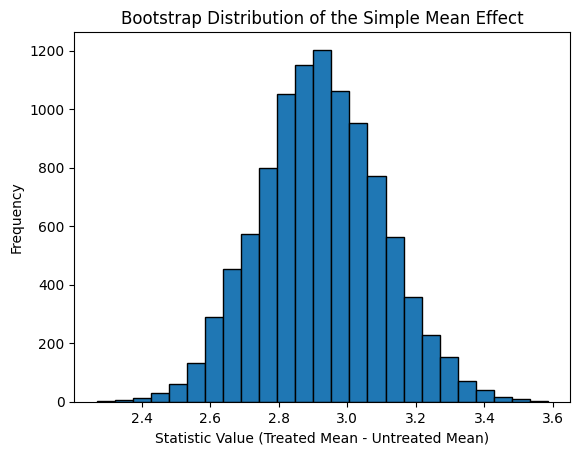

Mean Effect: BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(2.6363297982225995), high=np.float64(3.2239443074898784)), bootstrap_distribution=array([2.9670104 , 3.04271113, 2.86743151, ..., 2.57990562, 2.57842121,
       2.80334092]), standard_error=np.float64(0.17804067323624642))
Variance: 0.03169531116126672


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
from scipy.stats import skew

df2_2 = pd.read_csv('homework_2.2.csv')

def diff_in_means(treated, untreated):
    return np.mean(treated) - np.mean(untreated)

treated_data = df2_2[df2_2['X'] == 1]['Y'].values
untreated_data = df2_2[df2_2['X'] == 0]['Y'].values

res = bootstrap((treated_data, untreated_data), statistic=diff_in_means, confidence_level=0.9, vectorized=False)

fig, ax = plt.subplots()
ax.hist(res.bootstrap_distribution, bins=25, edgecolor='black')
ax.set_title('Bootstrap Distribution of the Simple Mean Effect')
ax.set_xlabel('Statistic Value (Treated Mean - Untreated Mean)')
ax.set_ylabel('Frequency')
plt.show()

#question 3:If we were to measure the effect of the treatment simply by subtracting the outcomes of the treated vs. untreated population, which of these is closest to the mean effect? (This is not the recommended way of measuring the mean effect when there are confounders!)
print(f'Mean Effect: {res}')

#question 4: If we were to use bootstrap sampling to measure the variance of that effect, again finding the effect using the non-recommended approach, which of these is closest to that variance?
variance = np.var(res.bootstrap_distribution)
print(f'Variance: {variance}')


In [ ]:
from scipy.stats import skew

#question 5:if we ran a linear regression (with intercept) to measure the effect, which of these is closest to the skewness of the effect measured? (Look up skewness online. You can use scipy.stats.skew to compute the skewness of a list of numbers.)


np.random.seed(42)
n = len(df2_2)
coefs = []

for _ in range(9999):
    sample = df2_2.sample(n, replace=True)
    X_samp = sample[['X']].values
    y_samp = sample['Y'].values
    model = LinearRegression().fit(X_samp, y_samp)
    coefs.append(model.coef_[0])

coefs = np.array(coefs)
answer_5 = skew(coefs)
print(f'Skew: {answer_5}')




Skew: 0.040688893952141834


**Reflection W2:**

 Write a Python program that performs a bootstrap simulation to find the variance in the mean of the Pareto distribution when different samples are taken. Explain what you had to do for this. As you make the full sample size bigger (for the same distribution), what happens to the variance of the mean of the samples? Does it stay about the same, get smaller, or get bigger?

In [ ]:
import numpy as np

alpha = 3.0
results = {}

for n in [50, 500, 5000, 50000]:
    pop = np.random.pareto(alpha, n)
    means = [np.mean(np.random.choice(pop, size=n, replace=True)) for _ in range(2000)]
    results[n] = np.var(means)
    print(f'n={n}: variance={results[n]:.6f}')

n=50: variance=0.004494
n=500: variance=0.001295
n=5000: variance=0.000104
n=50000: variance=0.000016


# Week 3

In [ ]:
df3_1 = pd.read_csv("homework_3.1.csv")
df3_2a = pd.read_csv("homework_3.2.a.csv")
df3_2b = pd.read_csv("homework_3.2.b.csv")


For questions 1 and 2:

Given a dataset with time series data containing an event, use a linear regression to test whether there was a discontinuity in the data at the event. Consider the possibility, first, of a discontinuity only in the value of the variable but not the derivative. Then consider that there may be a discontinuity in the first derivative (the slope).  
Use the file homework_3.1.csv.

In [ ]:
df3_1.head()

,time,value1,value2,value3
0,0,1.764052,1.883151,-0.369182
1,1,0.420157,-1.327759,-0.219379
2,2,1.018738,-1.230485,1.139660
3,3,2.300893,1.029397,0.715264
4,4,1.947558,-1.093123,0.720132


value1: discontinuity (jump) = -4.363, R² = 0.7897
value1: level jump = -4.363, slope change = 0.105, R² = 0.7897
value2: discontinuity (jump) = -1.145, R² = 0.5695
value2: level jump = -1.145, slope change = 0.037, R² = 0.5695
value3: discontinuity (jump) = -0.742, R² = 0.8072
value3: level jump = -0.742, slope change = 0.051, R² = 0.8072


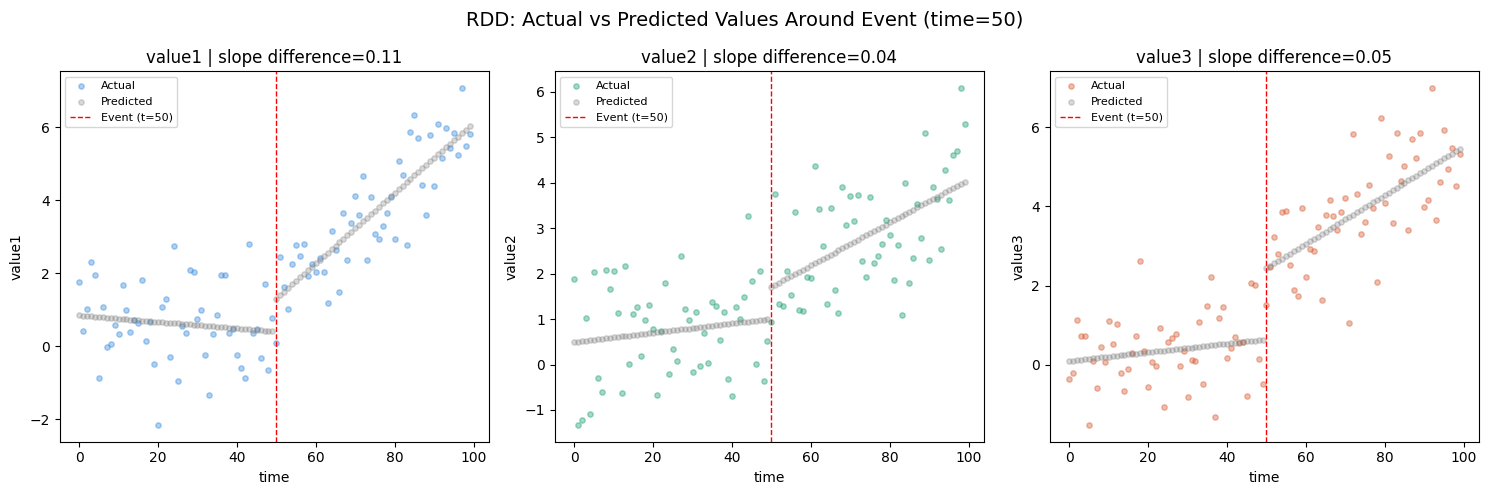

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create the post-event dummy
df3_1['post'] = (df3_1['time'] >= 50).astype(int)
df3_1['slope_differ'] = df3_1['time'] * df3_1['post']

features = ['value1', 'value2', 'value3']
colors = ['#378ADD', '#1D9E75', '#D85A30']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle('RDD: Actual vs Predicted Values Around Event (time=50)', fontsize=14)

for ax, feat, color in zip(axes, features, colors):
    X = df3_1[['time', 'post', 'slope_differ']]
    y = df3_1[feat]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    disc = model.coef_[1]  # coefficient on 'post'
    slope_disc = model.coef_[2] #coefficient on 'slope_differ'
    r2 = r2_score(y, y_pred)

    print(f"{feat}: discontinuity (jump) = {disc:.3f}, R² = {r2:.4f}")
    print(f"{feat}: level jump = {model.coef_[1]:.3f}, slope change = {slope_disc:.3f}, R² = {r2:.4f}")


    ax.scatter(df3_1['time'], y, alpha=0.4, s=15, color=color, label='Actual')
    ax.scatter(df3_1['time'], y_pred, alpha=0.3, s=15, color='gray', label='Predicted')
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1, label='Event (t=50)')
    ax.set_xlabel('time')
    ax.set_ylabel(feat)
    ax.set_title(f'{feat} | slope difference={slope_disc:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

For questions 3 to 5:  

Given a dataset with treatment and control data having “before” and “after” parts, apply a differences-in-differences regression.  
Use homework_3.2.a.csv and homework_3.2.b.csv.

In [ ]:
df3_2a.info()
df3_2b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   group1    1000 non-null   int64  
 1   time1     1000 non-null   int64  
 2   outcome1  1000 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 23.6 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   group2    1000 non-null   int64  
 1   time2     1000 non-null   int64  
 2   outcome2  1000 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 23.6 KB


In [ ]:
# Dataset A
df3_2a['treated'] = df3_2a['group1']
df3_2a['post'] = df3_2a['time1']
df3_2a['outcome'] = df3_2a['outcome1']

# Dataset B
df3_2b['treated'] = df3_2b['group2']
df3_2b['post'] = df3_2b['time2']
df3_2b['outcome'] = df3_2b['outcome2']

In [ ]:
import statsmodels.api as sm
# Create the post-event dummy
df3_2a['treated_post'] = df3_2a['treated'] * df3_2a['post'] # interaction term
df3_2b['treated_post'] = df3_2b['treated'] * df3_2b['post'] # interaction term

X_a = sm.add_constant(df3_2a[['treated', 'post', 'treated_post']])
results_a = sm.OLS(y_a, X_a).fit()
print(results_a.summary())

X_b = sm.add_constant(df3_2b[['treated', 'post', 'treated_post']])
results_b = sm.OLS(y_b, X_b).fit()
print(results_b.summary())


print(f"DiD estimate (β3 for 2a): {model_a.coef_[2]:.4f}")
print(f"DiD estimate (β3 for 2b): {model_b.coef_[2]:.4f}")



                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2964.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:08:21   Log-Likelihood:                -712.28
No. Observations:                1000   AIC:                             1433.
Df Residuals:                     996   BIC:                             1452.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0258      0.031     -0.829   

                            OLS Regression Results                            
Dep. Variable:              purchases   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     867.5
Date:                Sat, 06 Jun 2026   Prob (F-statistic):          3.28e-277
Time:                        18:32:25   Log-Likelihood:                -2112.7
No. Observations:                1000   AIC:                             4233.
Df Residuals:                     996   BIC:                             4253.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            9.9964      0.128     77.873   

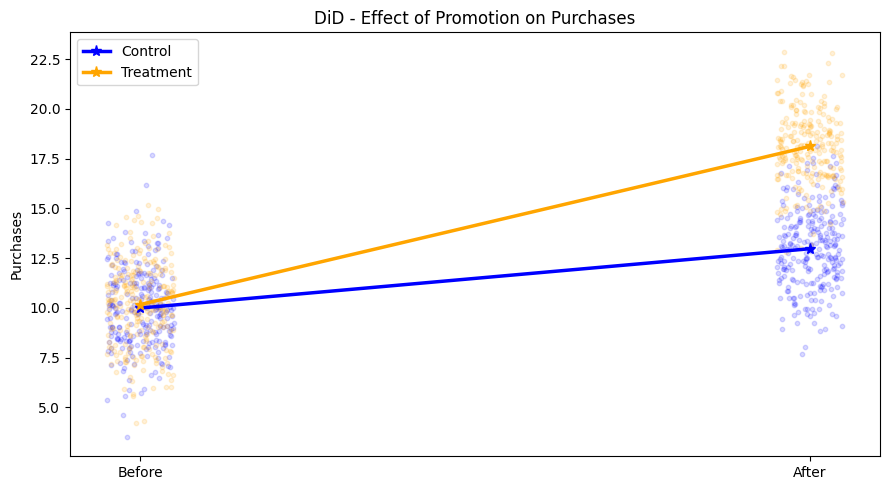

In [ ]:
#Homework Reflection
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500  # per group

# Simulate data
control = pd.DataFrame({
    'treated': 0,
    'post': np.random.randint(0, 2, n),
    'noise': np.random.normal(0, 2, n)
})

treatment = pd.DataFrame({
    'treated': 1,
    'post': np.random.randint(0, 2, n),
    'noise': np.random.normal(0, 2, n)
})

# Baseline purchases + time trend 
baseline = 10
time_trend = 3
treatment_effect = 5  

control['purchases'] = baseline + time_trend * control['post'] + control['noise']
treatment['purchases'] = baseline + time_trend * treatment['post'] + treatment_effect * (treatment['post']) + treatment['noise']

df = pd.concat([control, treatment], ignore_index=True)
df['treated_post'] = df['treated'] * df['post']

# DiD Regression
X = sm.add_constant(df[['treated', 'post', 'treated_post']])
y = df['purchases']
results = sm.OLS(y, X).fit()
print(results.summary())

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

colors = {'Control': 'blue', 'Treatment': 'orange'}
groups = [(0, 'Control'), (1, 'Treatment')]

for group_val, label in groups:
    means = []
    for period in [0, 1]:
        subset = df[(df['treated'] == group_val) & (df['post'] == period)]['purchases']
        jitter = np.random.uniform(-0.05, 0.05, len(subset))
        ax.scatter(period + jitter, subset, alpha=0.15, s=10, color=colors[label])
        means.append(subset.mean())
    # mean line to tell the difference in effect
    ax.plot([0, 1], means, color=colors[label], linewidth=2.5, marker='*', markersize=8, label=label)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Before', 'After'])
ax.set_ylabel('Purchases')
ax.set_title('DiD - Effect of Promotion on Purchases')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(df['treated'].unique())
print(df['post'].unique())
print(df.shape)

[0 1]
[0 1]
(1000, 5)


#Week 4

In [ ]:
import pandas as pd
df4 = pd.read_csv("homework_4.1.csv")
df4a = pd.read_csv("homework_4.2.a.csv")
df4b = pd.read_csv("homework_4.2.b.csv")

In [ ]:
# Simple Wald estimator
# (avg Y when Z=1 - avg Y when Z=0) / (avg X when Z=1 - avg X when Z=0)

y_diff = df4[df4['Z'] == 1]['Y'].mean() - df4[df4['Z'] == 0]['Y'].mean()
x_diff = df4[df4['Z'] == 1]['X'].mean() - df4[df4['Z'] == 0]['X'].mean()

iv_estimate = y_diff / x_diff
print(iv_estimate)

1.5618587073765746


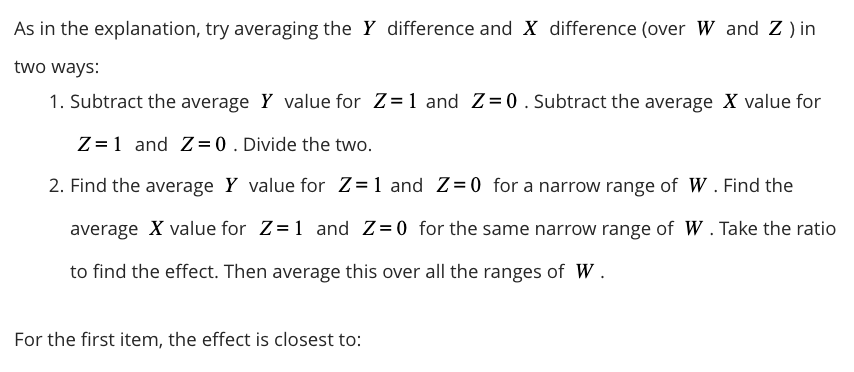

1.5, and did you need to know W to do this? No.

In [ ]:
# dataset a
import numpy as np
below_a = df4a[df4a['X'] < 80] #cutoff 80
above_a = df4a[df4a['X'] >= 80]

# fit the slope
slope_below_a = np.polyfit(below_a['X'], below_a['Y'], 1)[0]
slope_above_a = np.polyfit(above_a['X'], above_a['Y'], 1)[0]

print("Slope below:", slope_below_a)
print("Slope above:", slope_above_a)

Slope below: 0.00022383079714025536
Slope above: 0.00016108686490998425


In [ ]:
#dataset b
below_b = df4b[df4b['X2'] < 80]
above_b = df4b[df4b['X2'] >= 80]

#fit the slope
slope_below_b = np.polyfit(below_b['X2'], below_b['Y2'], 1)[0]
slope_above_b = np.polyfit(above_b['X2'], above_b['Y2'], 1)[0]

print("Slope below:", slope_below_b)
print("Slope above:", slope_above_b)

Slope below: 0.01021671127440077
Slope above: 0.0050086140682651156


Q3: The slope was lower

Q4: Which dataset needs a nonzero linear term? Dataset b had slopes of ~0.01 and ~0.005, so X predicted Y linearly on each side. Therfore, dataset B needs a non-linear term.

Q5: Y is increasing before the cutoff for dataset B.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Filter around the cutoff
window = 20  # ±20 points around 80
df_window = df4a[(df4a['X'] >= 80 - window) & (df4a['X'] <= 80 + window)].copy()

# Fit logistic regression to the data
X_vals = df_window[['X']]
y_vals = df_window['Y']

log_model = LogisticRegression()
log_model.fit(X_vals, y_vals)

# Predict probs + bin proportion
x_range = np.linspace(df_window['X'].min(), df_window['X'].max(), 300).reshape(-1, 1)
y_prob = log_model.predict_proba(x_range)[:, 1]

df_window['bin'] = pd.cut(df_window['X'], bins=20)
binned = df_window.groupby('bin')['Y'].mean().reset_index()
bin_centers = binned['bin'].apply(lambda x: x.mid)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(bin_centers, binned['Y'], color='purple', alpha = 0.7,label='Proportion')

# Logistic regression predicted probability
ax.plot(x_range, y_prob, color='darkorange', linewidth=2, label='Logistic regression')

# Cutoff line
ax.axvline(x=80, color='red', linestyle='--', linewidth=1.5, label='Cutoff')

ax.set_xlabel('Test Score')
ax.set_ylabel('College Outcome')
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'df4a' is not defined